# MNIST — TensorFlow/Keras *Hello World*

This notebook trains a tiny CNN on the MNIST dataset using **TensorFlow / Keras**.

**What it does**
- Loads MNIST (prefers `data/raw/mnist.npz` if present; otherwise uses Keras loader).
- Trains a small ConvNet for a few epochs.
- Evaluates test accuracy, prints a confusion matrix, and saves artifacts:
  - `results/models/mnist_cnn.keras`
  - `results/figures/mnist_confusion.png`
  - `results/tables/preds.csv`

> Folder layout assumed by your project tree.


In [1]:
# If you see import errors for TensorFlow, add one of these to your requirements and rebuild your container:
#   tensorflow==2.16.1            # (with GPU support where available)
#   # or CPU-only:
#   tensorflow-cpu==2.16.1
#
# Then restart the kernel.

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "1"  # 0: tüm loglar, 1: INFO susar, 2: WARNING susar
# os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # GPU'yu kapatmak isterseniz (sadece CPU için)
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"  # init'ten ÖNCE growth'u zorla

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Try TensorFlow import early to fail-fast if it's missing
import tensorflow as tf
import time

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import mixed_precision

gpus = tf.config.list_physical_devices('GPU')
print("GPUs:", gpus)
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)  # pre-alloc yerine gerektiği kadar kullan
    except Exception as e:
        print("Memory growth ayarlanamadı:", e)


print("Logical GPUs:", tf.config.list_logical_devices('GPU'))

with tf.device('/GPU:0'):
    a = tf.random.normal([4096, 4096])
    b = tf.random.normal([4096, 4096])
    t0 = time.time()
    c = tf.matmul(a, b)  # büyük matmul GPU'ya gider
    _ = c.numpy()
    print("GPU matmul süresi (s):", time.time()-t0)

# Optional tools
try:
    from sklearn.metrics import confusion_matrix
except Exception:
    confusion_matrix = None

mixed_precision.set_global_policy('mixed_float16')
# Son Dense(10) katmanını veya kayıpları float32'de tuttuğunuzdan emin olun (ör. Dense(..., dtype='float32'))

print("TensorFlow:", tf.__version__)
print("Keras backend:", keras.backend.backend())


2026-07-27 19:26:24.605159: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-27 19:26:24.618585: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-27 19:26:24.622710: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
I0000 00:00:1785169586.110777   63135 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1785169586.152525   63135 cuda_executor.cc:1015] succ

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Logical GPUs: [LogicalDevice(name='/device:GPU:0', device_type='GPU')]
GPU matmul süresi (s): 0.11715292930603027
INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 5050 Laptop GPU, compute capability 12.0
TensorFlow: 2.17.0
Keras backend: tensorflow


I0000 00:00:1785169586.673389   63135 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355


In [3]:
# Reproducibility & folders
import random

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

ROOT = Path('.')
DATA_DIR = ROOT / '../data'
RAW = DATA_DIR / 'raw'
RESULTS = ROOT / '../results'
FIGS = RESULTS / 'figures'
MODELS = RESULTS / 'models'
TABLES = RESULTS / 'tables'

for p in [DATA_DIR, RAW, RESULTS, FIGS, MODELS, TABLES]:
    p.mkdir(parents=True, exist_ok=True)

print("Directories ready.")    


Directories ready.


In [4]:
# Data loading utility: prefer local file, else use Keras
# Local expected path: data/raw/mnist.npz
# If offline, download mnist.npz manually into data/raw and re-run.

def load_mnist_local_first():
    local = RAW / 'mnist.npz'
    if local.exists():
        with np.load(local, allow_pickle=True) as f:
            x_train, y_train = f['x_train'], f['y_train']
            x_test, y_test = f['x_test'], f['y_test']
        print(f"Loaded MNIST from {local} →",
              f"x_train:{x_train.shape} x_test:{x_test.shape}")
    else:
        print("Local data/raw/mnist.npz not found; using Keras loader (will download if not cached).")
        (x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
        # Optionally cache to data/raw for next time
        np.savez_compressed(local, x_train=x_train, y_train=y_train, x_test=x_test, y_test=y_test)
        print(f"Cached MNIST to {local}")
    return (x_train, y_train), (x_test, y_test)

(x_train, y_train), (x_test, y_test) = load_mnist_local_first()

# Normalize and add channel dimension
x_train = (x_train.astype('float32') / 255.0)[..., np.newaxis]  # (N,28,28,1)
x_test  = (x_test.astype('float32')  / 255.0)[..., np.newaxis]

print("x_train:", x_train.shape, "x_test:", x_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)


Loaded MNIST from ../data/raw/mnist.npz → x_train:(60000, 28, 28) x_test:(10000, 28, 28)
x_train: (60000, 28, 28, 1) x_test: (10000, 28, 28, 1)
y_train: (60000,) y_test: (10000,)


In [5]:
# Model — a tiny CNN good enough for a quick demo
model = keras.Sequential([
    layers.Input(shape=(28,28,1)),
    layers.Conv2D(16, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax'),
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 16)        160       
                                                                 
 max_pooling2d (MaxPooling2  (None, 13, 13, 16)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 32)        4640      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 5, 5, 32)          0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 800)               0         
                                                                 
 dense (Dense)               (None, 64)                5

In [6]:
# Train (keep epochs small for a quick 'hello world')
history = model.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=3,
    batch_size=128,
    verbose=1
)

# Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f} | Test loss: {test_loss:.4f}")


Epoch 1/3


2026-07-27 19:26:57.068979: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
W0000 00:00:1785169617.223816   63262 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785169617.224962   63262 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785169617.225823   63262 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785169617.226685   63262 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785169617.236145   63262 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduc

  5/422 [..............................] - ETA: 14s - loss: 2.2695 - accuracy: 0.1547 

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
W0000 00:00:1785169618.034009   63246 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785169618.034264   63246 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785169618.034305   63246 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785169618.034347   63246 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785169618.034409   63246 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785169618.034525   63246 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785169618.034655   63246 gpu_timer.cc:114] Skipping

 54/422 [==>...........................] - ETA: 2s - loss: 1.2494 - accuracy: 0.6685

...

W0000 00:00:1785169621.665313   63244 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785169621.665444   63244 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785169621.665504   63244 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785169621.665581   63244 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785169621.665676   63244 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785169621.665766   63244 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785169621.665845   63244 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785169621.665957   63244 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785169621.666051   63244 gp

422/422 [==============================] - 2s 5ms/step - loss: 0.0627 - accuracy: 0.9801 - val_loss: 0.0555 - val_accuracy: 0.9848


W0000 00:00:1785169623.804766   63244 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785169623.804916   63244 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785169623.804962   63244 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785169623.805013   63244 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785169623.805081   63244 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785169623.805151   63244 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785169623.805214   63244 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785169623.805308   63244 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785169623.805386   63244 gp

Test accuracy: 0.9820 | Test loss: 0.0530


W0000 00:00:1785169624.359970   63266 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785169624.360121   63266 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785169624.360170   63266 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785169624.360205   63266 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785169624.360250   63266 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785169624.360296   63266 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785169624.360336   63266 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785169624.360405   63266 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785169624.360467   63266 gp

W0000 00:00:1785169645.900266   63261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785169645.900447   63261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785169645.900522   63261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785169645.900594   63261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785169645.900655   63261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785169645.900734   63261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785169645.900802   63261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785169645.900887   63261 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785169645.900982   63261 gp

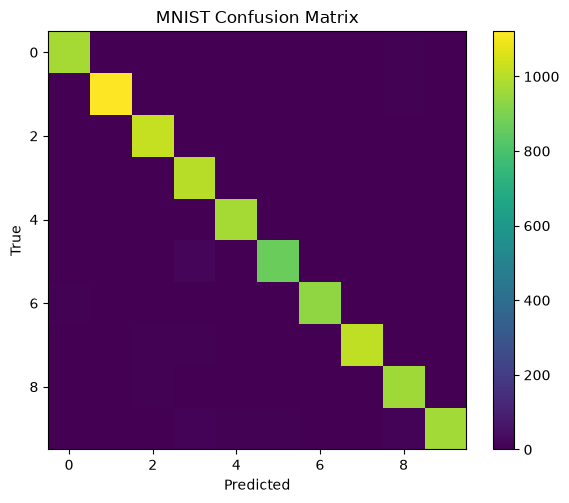

Saved confusion matrix → ../results/figures/mnist_confusion.png


In [7]:
# Predictions & confusion matrix
y_pred = np.argmax(model.predict(x_test, verbose=0), axis=1)

if confusion_matrix is not None:
    cm = confusion_matrix(y_test, y_pred)
    fig = plt.figure(figsize=(6,5))
    plt.imshow(cm, interpolation='nearest')
    plt.title('MNIST Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.colorbar()
    plt.tight_layout()
    fig_path = FIGS / 'mnist_confusion.png'
    plt.savefig(fig_path, dpi=150)
    plt.show()
    print(f"Saved confusion matrix → {fig_path}")
else:
    print("sklearn not available; skipping confusion matrix plot.")


In [8]:
# Save artifacts
model_path = MODELS / 'mnist_cnn.keras'
model.save(model_path)
print(f"Saved model → {model_path}")

# Save a small predictions CSV
import pandas as pd
sample_idx = np.arange(1000)
df = pd.DataFrame({
    'index': sample_idx,
    'true': y_test[sample_idx],
    'pred': y_pred[sample_idx]
})
csv_path = TABLES / 'preds.csv'
df.to_csv(csv_path, index=False)
print(f"Saved predictions sample → {csv_path}")

Saved model → ../results/models/mnist_cnn.keras
Saved predictions sample → ../results/tables/preds.csv


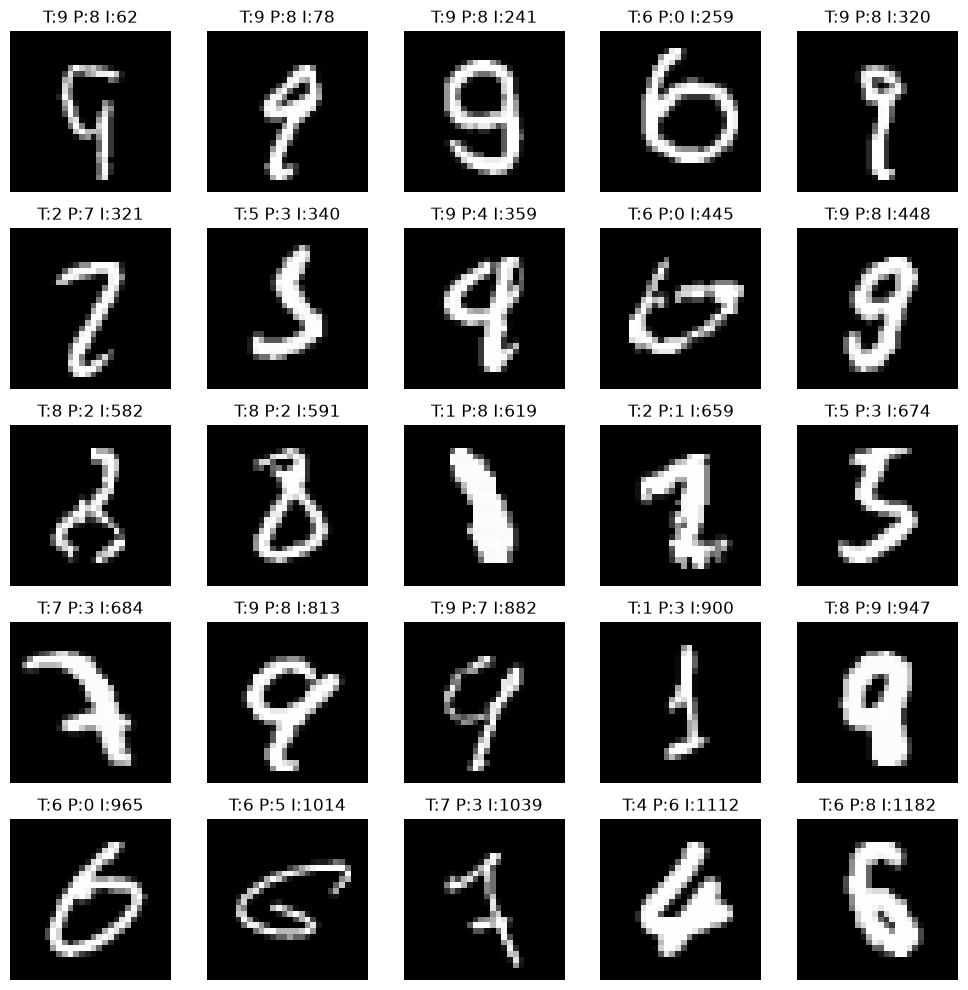

In [9]:
# Visualize some mistakes
mis = np.where(y_pred != y_test)[0][:25]
if mis.size > 0:
    cols = 5
    rows = int(np.ceil(len(mis)/cols))
    plt.figure(figsize=(10, 2*rows))
    for i, idx in enumerate(mis[:rows*cols]):
        plt.subplot(rows, cols, i+1)
        plt.imshow(x_test[idx].squeeze(), cmap='gray')
        plt.title(f"T:{y_test[idx]} P:{y_pred[idx]} I:{idx}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("No misclassifications in the sampled subset (unusual but possible).")
